# Visualisation de la rigidité oculaire

Représentation graphique de la table `rigidity_time_series.csv` produite par
`compute_rigidity_time_series.py`.

Étapes :
1. **Identifiants** — extraction du patient, de l'œil (OD/OS), de la phase
   (`before`/`post`) et du numéro de réplicat depuis les noms de dossiers.
2. **Réplicats** — comparaison des mesures répliquées (même patient, même œil,
   même moment).
3. **Agrégation** — moyenne des réplicats → une valeur par (patient, œil, phase).
4. **Apparié avant/après** — deux boxplots (avant / après), points individuels,
   et une ligne reliant chaque œil de son état *avant* à son état *après*.


In [122]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Chemin du CSV produit par compute_rigidity_time_series.py ---
CSV_PATH = Path("E:/SANSORI/rigidity_time_series.csv")
# Si le notebook est lancé à côté du CSV, utilise plutôt :
# CSV_PATH = Path("rigidity_time_series.csv")

# Colonnes numériques. AL provient de la base sansori_db.db ;
# IOP/OPA de visit_data.csv. Les valeurs manquantes sont écrites "<NA>"
# par compute_rigidity_time_series.py (k n'est pas calculé quand AL, IOP
# ou OPA manque). pd.read_csv reconnaît "<NA>" comme manquant ; la coercion
# garantit le type float même si une colonne est entièrement vide.
NUM_COLS = ["hr", "AL", "IOP", "OPA", "CT", "delta_CT", "delta_V", "k"]

df = pd.read_csv(CSV_PATH)
df[NUM_COLS] = df[NUM_COLS].apply(pd.to_numeric, errors="coerce")
print(f"{len(df)} lignes chargées")
df.head()


101 lignes chargées


,patient,moment,condition,path,hr,AL,IOP,OPA,CT,delta_CT,delta_V,k
0,01_210713001,210713001before_rigidity,210713001before_rigidity_OD,E:\SANSORI\01_210713001\210713001before_rigidi...,63.0,23.15,17.7,2.6,0.2574,0.003213,2.099920,0.065267
1,01_210713001,210713001before_rigidity,210713001before_rigidity_OS1,E:\SANSORI\01_210713001\210713001before_rigidi...,63.0,23.11,15.9,2.5,0.2574,0.007317,4.765944,0.030641
2,01_210713001,210713001before_rigidity,210713001before_rigidity_OS2,E:\SANSORI\01_210713001\210713001before_rigidi...,63.0,23.11,15.9,2.5,0.2613,0.007425,4.838216,0.030183
3,01_210713001,210713001post_rigidity,210713001post_rigidity_OD1,E:\SANSORI\01_210713001\210713001post_rigidity...,67.0,23.04,12.9,1.7,0.2847,0.005492,3.565407,0.034721
4,01_210713001,210713001post_rigidity,210713001post_rigidity_OD2,E:\SANSORI\01_210713001\210713001post_rigidity...,67.0,23.04,12.9,1.7,0.2535,0.003898,2.522951,0.049067


## Sources et données manquantes

- **AL** : longueur axiale lue dans la base `sansori_db.db` (table `Measurements`,
  description `Biometry`), appariée par (code astronaute, œil, moment).
- **IOP / OPA** : lus dans `visit_data.csv` (`PascalIOP` / `PascalOPA`).
- Une valeur absente est écrite `<NA>` ; **`k` n'est calculé que si AL, IOP et OPA
  sont tous disponibles**. Les cellules ci-dessous ignorent automatiquement les `<NA>`.


In [123]:
# --- Aperçu des valeurs manquantes (<NA>) ---
na_counts = df[NUM_COLS].isna().sum()
print("Valeurs manquantes par colonne :")
print(na_counts[na_counts > 0].to_string() if na_counts.any() else "  aucune")

n_al = int(df["AL"].notna().sum())
n_k = int(df["k"].notna().sum())
print(f"\nAL renseignée (base) : {n_al}/{len(df)} conditions")
print(f"k calculé            : {n_k}/{len(df)} conditions "
      f"(nécessite AL [base] + IOP + OPA [visit_data])")


Valeurs manquantes par colonne :
AL         25
delta_V    25
k          25

AL renseignée (base) : 76/101 conditions
k calculé            : 76/101 conditions (nécessite AL [base] + IOP + OPA [visit_data])


## 1. Extraction des identifiants

- `patient` `01_210713001` → **patient** = `01`
- `moment` `210713001before_rigidity` → **phase** = `before` ou `post`
- `condition` `210713001before_rigidity_OD` → **œil** = `OD`/`OS`
  (un chiffre éventuel en suffixe, ex. `OS4`, donne le **réplicat**)


In [124]:
def parse_patient(s):
    # '01_210713001' -> '01'
    return str(s).split("_")[0]

def parse_phase(s):
    s = str(s).lower()
    if "before" in s:
        return "before"
    if "post" in s:
        return "post"
    return np.nan

def parse_eye_replicate(s):
    # '...rigidity_OD' -> ('OD', <NA>) ; '...rigidity_OS4' -> ('OS', 4)
    tail = str(s).split("_")[-1]
    m = re.match(r"(OD|OS)(\d?)", tail, flags=re.IGNORECASE)
    if not m:
        return np.nan, pd.NA
    eye = m.group(1).upper()
    rep = int(m.group(2)) if m.group(2) else pd.NA
    return eye, rep

df["patient_id"] = df["patient"].map(parse_patient)
df["phase"] = df["moment"].map(parse_phase)
_eye_rep = df["condition"].map(parse_eye_replicate)
df["eye"] = [er[0] for er in _eye_rep]
df["replicate"] = [er[1] for er in _eye_rep]

# ordre logique des phases pour l'affichage
df["phase"] = pd.Categorical(df["phase"], categories=["before", "post"], ordered=True)

df[["patient_id", "phase", "eye", "replicate", "k"]].head(10)


,patient_id,phase,eye,replicate,k
0,01,before,OD,<NA>,0.065267
1,01,before,OS,1,0.030641
2,01,before,OS,2,0.030183
3,01,post,OD,1,0.034721
4,01,post,OD,2,0.049067
5,01,post,OS,1,0.076808
6,02,before,OD,<NA>,0.060683
7,02,before,OS,<NA>,0.080388
8,02,post,OD,<NA>,0.043906
9,02,post,OS,1,0.124835


In [125]:
# Grandeurs à représenter et unités
METRICS = ["k", "delta_V", "delta_CT", "CT",  "AL", "IOP", "OPA"]
PRIMARY = "k"   # grandeur principale : coefficient de rigidité
PRIMARY = "delta_CT"   # grandeur principale : volume pulsatile
PRIMARY = "CT"  # grandeur principale : épaisseur cornéenne centrale
UNITS = {"k": "mm⁻³", "delta_V": "mm³", "delta_CT": "mm", "CT": "mm",
         "hr": "BPM", "AL": "mm", "IOP": "mmHg", "OPA": "mmHg"}


## 2. Comparaison des réplicats

Un *réplicat* = mesure répétée pour le même **patient**, même **œil**, même
**phase**. On vérifie d'abord leur cohérence avant de les agréger.


In [126]:
group_keys = ["patient_id", "eye", "phase"]
g = df.groupby(group_keys, observed=True)

rep_stats = g[PRIMARY].agg(n="count", mean="mean", std="std")
rep_stats["cv_%"] = 100 * rep_stats["std"] / rep_stats["mean"].abs()

replicated = rep_stats[rep_stats["n"] > 1].copy()
print(f"{len(replicated)} échantillons répliqués (n>1) sur {len(rep_stats)} au total")
replicated.sort_values("cv_%", ascending=False)


40 échantillons répliqués (n>1) sur 52 au total


,,,n,mean,std,cv_%
patient_id,eye,phase,,,,
07,OD,before,2,0.333450,0.046881,14.059429
12,OS,before,2,0.349050,0.046881,13.431079
04,OD,before,2,0.267150,0.030335,11.355002
05,OS,post,2,0.302250,0.030335,10.036355
04,OS,post,2,0.274950,0.024819,9.026895
01,OD,post,2,0.269100,0.022062,8.198345
07,OD,post,2,0.310050,0.024819,8.004982
06,OD,post,2,0.388050,0.030335,7.817265
13,OS,before,2,0.374400,0.027577,7.365692


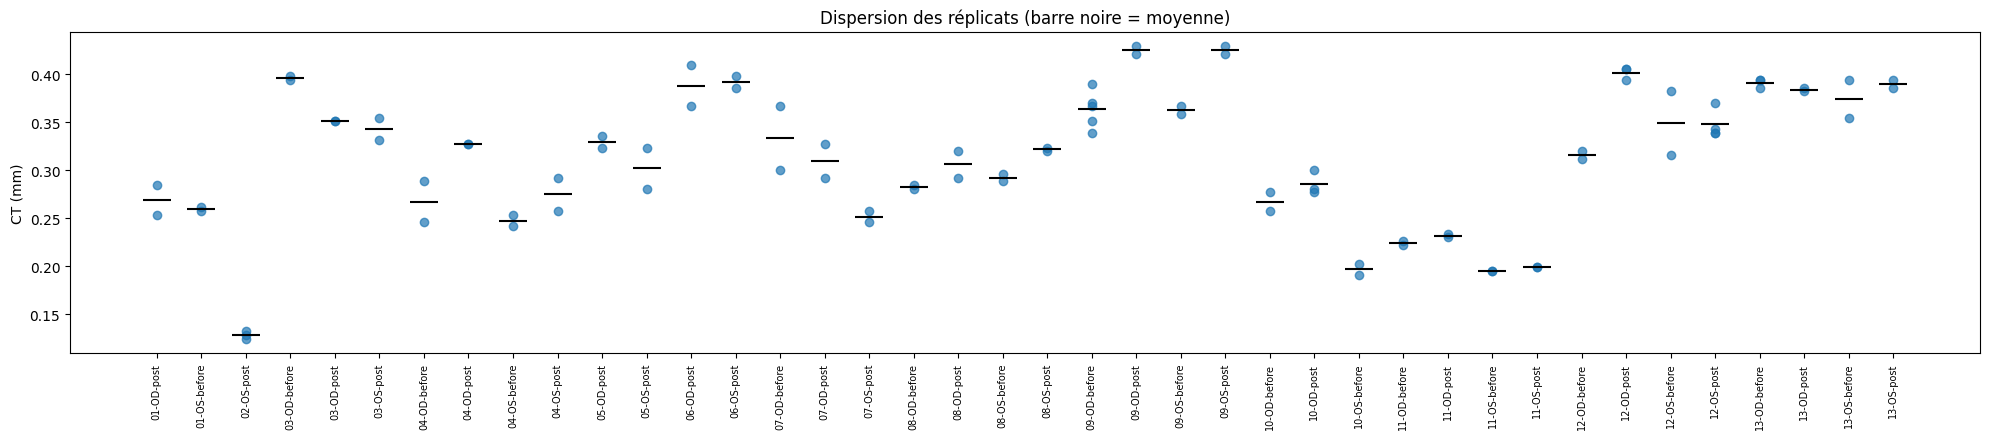

In [127]:
# Dispersion des réplicats pour la grandeur principale
sub = df.copy()
sub["sample"] = (sub["patient_id"].astype(str) + "-"
                 + sub["eye"].astype(str) + "-"
                 + sub["phase"].astype(str))
is_rep = sub.groupby("sample", observed=True)[PRIMARY].transform("count") > 1
sub_rep = sub[is_rep]

if len(sub_rep):
    order = sorted(sub_rep["sample"].unique())
    fig, ax = plt.subplots(figsize=(max(6, 0.5 * len(order)), 4.5))
    for i, s in enumerate(order):
        vals = sub_rep.loc[sub_rep["sample"] == s, PRIMARY].values
        ax.scatter(np.full(vals.size, i), vals, alpha=0.7, color="#1f77b4")
        ax.scatter(i, np.mean(vals), marker="_", s=400, color="k", zorder=3)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=90, fontsize=7)
    ax.set_ylabel(f"{PRIMARY} ({UNITS.get(PRIMARY, '')})")
    ax.set_title("Dispersion des réplicats (barre noire = moyenne)")
    fig.tight_layout()
    plt.show()
else:
    print("Aucun échantillon répliqué (n>1).")


## 3. Agrégation des réplicats

Moyenne des réplicats → **une valeur par (patient, œil, phase)**.
C'est l'unité statistique du graphique apparié.


In [128]:
agg = (df.groupby(["patient_id", "eye", "phase"], observed=True)[METRICS]
         .mean()
         .reset_index())
agg["n_replicates"] = (df.groupby(["patient_id", "eye", "phase"], observed=True)[PRIMARY]
                         .count().values)
print(f"{len(agg)} échantillons agrégés")
agg.head()


52 échantillons agrégés


,patient_id,eye,phase,k,delta_V,delta_CT,CT,AL,IOP,OPA,n_replicates
0,01,OD,before,0.065267,2.099920,0.003213,0.25740,23.15,17.7,2.6,1
1,01,OD,post,0.041894,3.044179,0.004695,0.26910,23.04,12.9,1.7,2
2,01,OS,before,0.030412,4.802080,0.007371,0.25935,23.11,15.9,2.5,2
3,01,OS,post,0.076808,1.783957,0.002766,0.28860,22.96,14.3,2.1,1
4,02,OD,before,0.060683,3.156358,0.004010,0.15600,25.55,18.0,3.8,1


## 4. Graphique apparié avant / après

Deux boxplots (avant / après), les points individuels colorés par œil, et une
ligne grise reliant chaque œil de son état *avant* à son état *après*.


In [129]:
EYE_COLORS = {"OD": "#1f77b4", "OS": "#d62728"}
X_BEFORE, X_POST = 1.0, 2.0          # positions des boxplots
X_PTS_BEFORE, X_PTS_POST = 1.30, 1.70  # positions des points/lignes (entre les box)

def paired_before_after(agg, metric, ax=None):
    """Boxplots avant/après + points individuels + lignes appariées (par œil)."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))

    piv = agg.pivot_table(index=["patient_id", "eye"], columns="phase",
                          values=metric, observed=True)
    for c in ["before", "post"]:
        if c not in piv.columns:
            piv[c] = np.nan
    piv = piv[["before", "post"]]

    before = piv["before"].values.astype(float)
    post = piv["post"].values.astype(float)

    # --- boxplots ---
    bp = ax.boxplot([before[np.isfinite(before)], post[np.isfinite(post)]],
                    positions=[X_BEFORE, X_POST], widths=0.45,
                    showfliers=False, patch_artist=True,
                    medianprops=dict(color="black", lw=1.5))
    for patch in bp["boxes"]:
        patch.set(facecolor="0.93", edgecolor="0.5")

    # --- points + lignes appariées ---
    seen = set()
    for (pid, eye), row in piv.iterrows():
        b, p = row["before"], row["post"]
        col = EYE_COLORS.get(eye, "gray")
        if np.isfinite(b) and np.isfinite(p):
            ax.plot([X_PTS_BEFORE, X_PTS_POST], [b, p],
                    color="0.75", lw=0.8, zorder=1)
        if np.isfinite(b):
            ax.scatter(X_PTS_BEFORE, b, color=col, s=28, zorder=2,
                       label=(eye if eye not in seen else None))
            seen.add(eye)
        if np.isfinite(p):
            ax.scatter(X_PTS_POST, p, color=col, s=28, zorder=2,
                       label=(eye if eye not in seen else None))
            seen.add(eye)

    n_pairs = int((np.isfinite(before) & np.isfinite(post)).sum())
    ax.set_xticks([X_BEFORE, X_POST])
    ax.set_xticklabels(["Avant", "Après"])
    ax.set_xlim(0.5, 2.5)
    ax.set_ylabel(f"{metric} ({UNITS.get(metric, '')})")
    ax.set_title(f"{metric} : avant vs après vol")
    ax.legend(title=f"œil (paires = {n_pairs})", fontsize=8)
    return ax


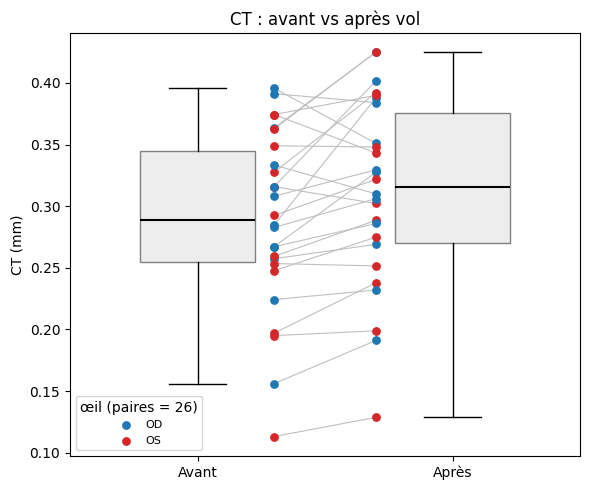

In [130]:
# Grandeur principale
fig, ax = plt.subplots(figsize=(6, 5))
paired_before_after(agg, PRIMARY, ax=ax)
fig.tight_layout()
plt.show()


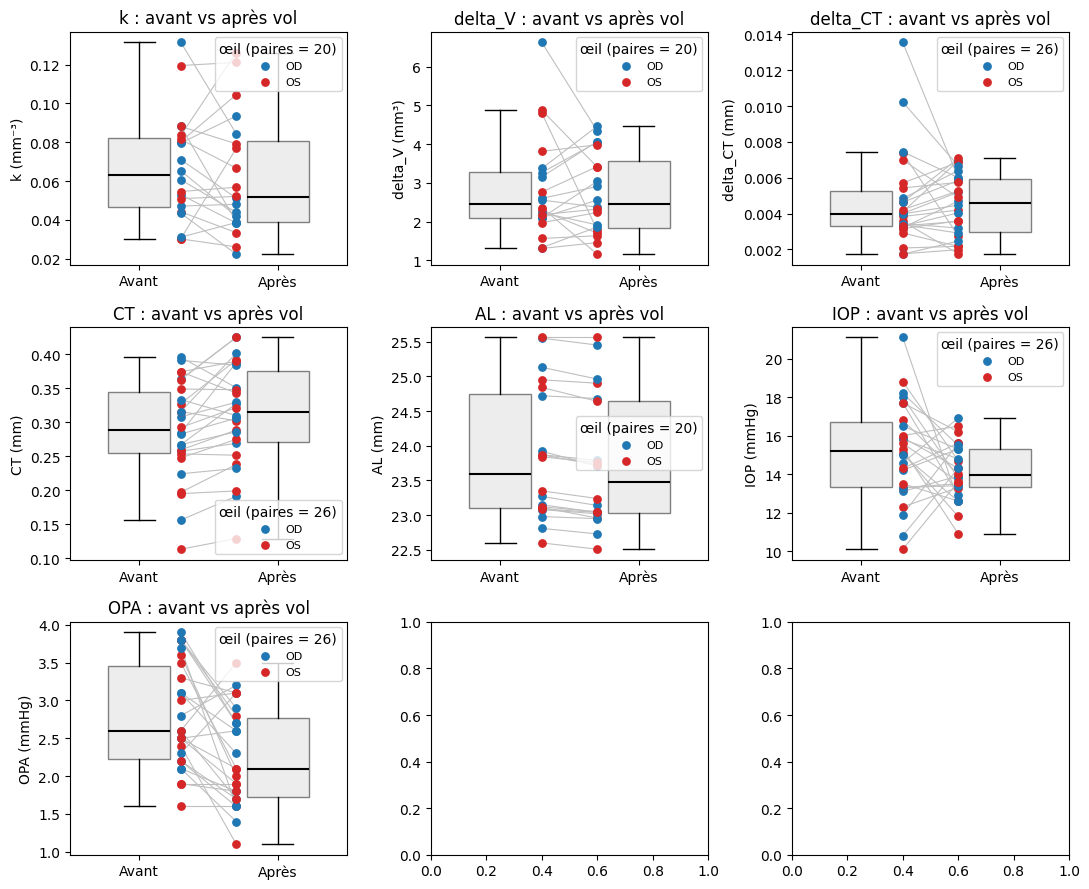

In [136]:
# Toutes les grandeurs
fig, axes = plt.subplots(3, 3, figsize=(11, 9))
for ax, metric in zip(axes.ravel(), METRICS):
    paired_before_after(agg, metric, ax=ax)
fig.tight_layout()
plt.show()


## 5. Test apparié (Wilcoxon)

Test des rangs signés de Wilcoxon sur les paires avant/après (un œil = une paire).


In [132]:
from scipy.stats import wilcoxon

def paired_test(agg, metric):
    piv = agg.pivot_table(index=["patient_id", "eye"], columns="phase",
                          values=metric, observed=True)
    if not {"before", "post"} <= set(piv.columns):
        return dict(metric=metric, n=0, delta_median=np.nan, p=np.nan)
    paired = piv.dropna(subset=["before", "post"])
    if len(paired) < 3:
        return dict(metric=metric, n=len(paired), delta_median=np.nan, p=np.nan)
    _, p = wilcoxon(paired["before"], paired["post"])
    return dict(metric=metric, n=len(paired),
                delta_median=float(np.median(paired["post"] - paired["before"])),
                p=float(p))

pd.DataFrame([paired_test(agg, m) for m in METRICS]).set_index("metric")


,n,delta_median,p
metric,,,
k,20,-0.006520,0.294252
delta_V,20,0.159824,0.812355
delta_CT,26,0.000332,0.652813
CT,26,0.020150,0.003229
AL,20,-0.085000,0.000131
IOP,26,-1.100000,0.088793
OPA,26,-0.550000,0.001932


## 6. Relations entre grandeurs

`delta_CT` vs `CT`, `k` vs `CT`, `k` vs `delta_CT`.
Couleurs distinctes selon la phase : **avant** (bleu) / **après** (rouge).


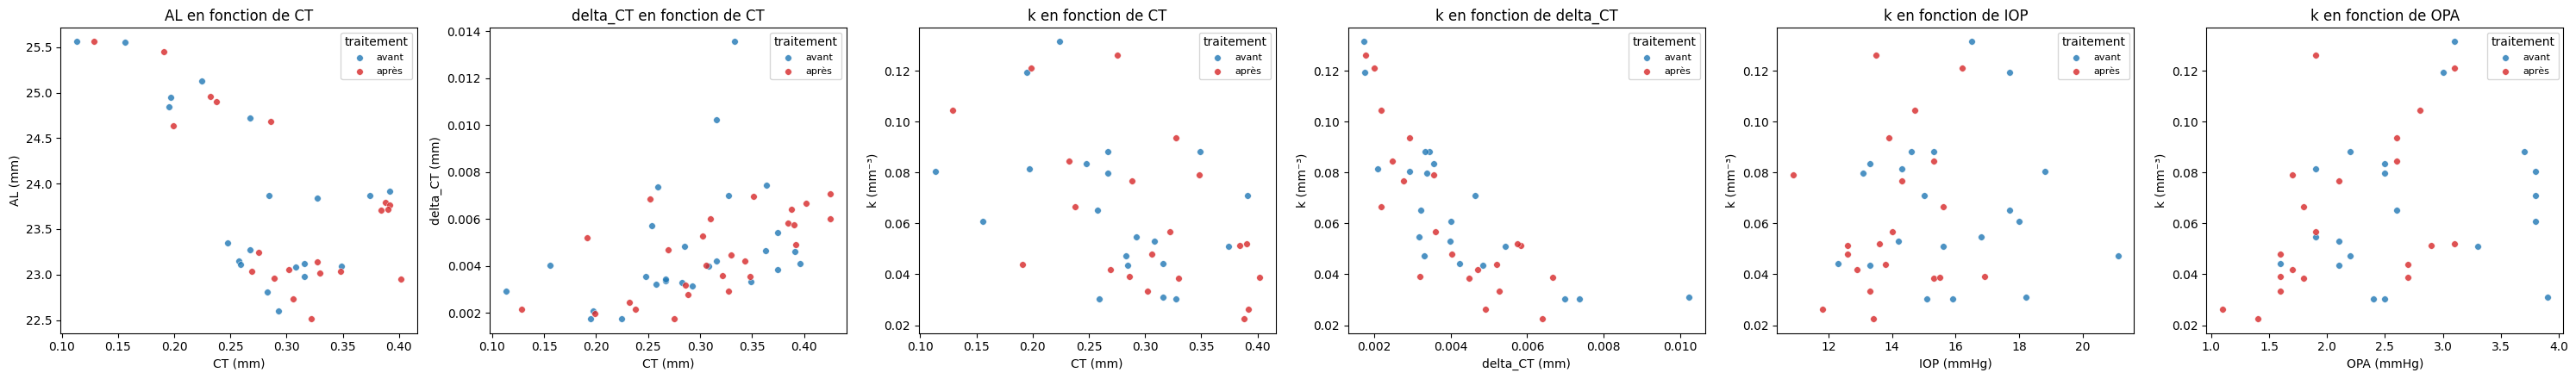

In [ ]:
PHASE_COLORS = {"before": "#1f77b4", "post": "#d62728"}
PHASE_LABELS = {"before": "avant", "post": "après"}

pairs = [("CT", "AL"), ("CT", "delta_CT"), ("CT", "k"), ("delta_CT", "k"), ("IOP", "k"), ("OPA", "k"), ("IOP", "OPA")]

fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4.5))
for ax, (xcol, ycol) in zip(axes, pairs):
    for phase, color in PHASE_COLORS.items():
        d = agg[agg["phase"] == phase]
        ax.scatter(d[xcol], d[ycol], color=color, s=30, alpha=0.8,
                   edgecolor="white", linewidth=0.4, label=PHASE_LABELS[phase])
    ax.set_xlabel(f"{xcol} ({UNITS.get(xcol, '')})")
    ax.set_ylabel(f"{ycol} ({UNITS.get(ycol, '')})")
    ax.set_title(f"{ycol} en fonction de {xcol}")
    ax.legend(title="traitement", fontsize=8)
fig.tight_layout()
plt.show()


In [134]:
# (optionnel) sauvegarde de la table agrégée
agg.to_csv(CSV_PATH.with_name("rigidity_aggregated.csv"), index=False)
print("Table agrégée enregistrée :", CSV_PATH.with_name("rigidity_aggregated.csv"))


Table agrégée enregistrée : E:\SANSORI\rigidity_aggregated.csv
